In [1]:
import msprime 
import dpluspy 
import numpy as np
import pandas
import demes

In [2]:
def compute_numer_onepop(
    genotypes, 
    rec_map,
    bins, 
    mut_map, 
    u_bar, 
    verbose=False
):
    """
    Compute the numerator of the u-adjusted statistic. This is

    u_bar ** 2 * sum_(i,j) D+(i,j) / (u_i * u_j),

    and the whole estimator is

    u_bar ** 2 / n_pairs * sum_(i,j) D+(i,j) / (u_i * u_j)

    :param genotypes: Array of genotypes for a single diploid
    :param rec_map: Array of recombination map coordinates for genotyped sites
    :param bins: Array of recombination bin edges
    :param mut_map: Array of estimated mutation rates at genotyped sites
    """
    # indicator for one-locus heterozygosity
    indicator = 1.0 * (genotypes[:, 0] != genotypes[:, 1])
    weights = u_bar / mut_map
    indicator *= weights

    stats = dpluspy.parsing._count_locus_pairs(
        rec_map, 
        bins,
        weights=indicator,
        verbose=verbose
    )

    stats = np.append(stats, 0)

    return stats


def compute_numer_onepop_between(
    left_genotypes,
    right_genotypes,
    left_rec_map,
    right_rec_map,
    bins, 
    left_mut_map, 
    right_mut_map,
    u_bar, 
    verbose=False
):
    """
    Compute the numerator of the u-adjusted statistic between two genomic
    intervals. This is

    u_bar ** 2 * sum_(i,j) D+(i,j) / (u_i * u_j),

    and the whole estimator is

    u_bar ** 2 / n_pairs * sum_(i,j) D+(i,j) / (u_i * u_j)

    :param genotypes: Array of genotypes for a single diploid
    :param rec_map: Array of recombination map coordinates for genotyped sites
    :param bins: Array of recombination bin edges
    :param mut_map: Array of estimated mutation rates at genotyped sites
    """
    # indicators for one-locus heterozygosity
    left_indicator = 1.0 * (left_genotypes[:, 0] != left_genotypes[:, 1])
    left_weights = u_bar / left_mut_map
    left_indicator *= left_weights

    right_indicator = 1.0 * (right_genotypes[:, 0] != right_genotypes[:, 1])
    right_weights = u_bar / right_mut_map
    right_indicator *= right_weights

    stats = dpluspy.parsing._count_locus_pairs_between(
        left_rec_map, 
        right_rec_map,
        bins,
        left_weights=left_indicator,
        right_weights=right_indicator,
        verbose=verbose
    )

    stats = np.append(stats, 0)
    
    return stats

def compute_adjusted_stats(
    genotypes,
    sites,
    rec_map,
    bins,
    mut_map,
    intervals,
    u_bar,
    chrom="None",
    verbose=True
):  
    """
    Works for one array of genotypes
    """
    ret_bins = bins
    bins = dpluspy.utils._map_function(bins) 
    ret = dict()

    for ii, interval in enumerate(intervals):
        assert len(interval) == 3
        interval0 = interval[:2]
        interval1 = interval[1:]
        
        where = np.where((sites >= interval0[0]) & (sites < interval0[1]))[0]
        sums = compute_numer_onepop(
            genotypes[where], 
            rec_map[where],
            bins, 
            mut_map[where], 
            u_bar
        )
        if interval1[1] > interval1[0]:
            left_where = np.where((sites >= interval0[0]) & (sites < interval0[1]))[0]
            right_where = np.where((sites >= interval1[0]) & (sites < interval1[1]))[0]
            sums += compute_numer_onepop_between(
                genotypes[left_where],
                genotypes[right_where],
                rec_map[left_where],
                rec_map[right_where],
                bins, 
                mut_map[left_where], 
                mut_map[right_where],
                u_bar
            )
        stats = dict()
        stats["bins"] = ret_bins
        stats["sums"] = sums

        key = (chrom, ii)
        ret[key] = stats

        if verbose:
            if interval1[1] > interval1[0]:
                print(dpluspy.utils._current_time(), 
                    f"Computed stats in chrom {chrom} interval {ii} "
                    f"{interval[0]}:{interval[1]}:{interval[2]}")
            else:
                print(dpluspy.utils._current_time(), 
                    f"Computed stats in chrom {chrom} interval {ii} "
                    f"{interval[0]}:{interval[1]}")
    
    return ret

In [9]:
chrom = 22
rec_map_fname = f"../data/recombination_maps/Bherer_b37/sexavg_chr{chrom}.txt.gz"
mut_map_fname = f"../data/mutation_maps/roulette_b37_10kb/roulette_10kb_chr{chrom}.csv.gz"
mask_fname = f"../data/bed_files/filterbed_1e-4M_exon_buffer/mask_chr{chrom}.bed.gz"
window_fname = f"../data/intervals/1e-4_exon_buffer_1.3Mb/intervals_chr{chrom}.txt"
graph_fname = "graph.yaml"
pop_ids = ["PopX", "PopY"]

In [10]:
mut_df = pandas.read_csv(mut_map_fname)
edges = np.append(
    np.array(mut_df["chromStart"]), np.array(mut_df["chromEnd"])[-1])
vals = np.array(mut_df["mut_map"])
vals[np.isnan(vals)] = 0
sim_mut_map = msprime.RateMap(position=edges, rate=vals)


# Load recombination map
sequence_length = edges[-1]
sim_rec_map = msprime.RateMap.read_hapmap(
    rec_map_fname, sequence_length=sequence_length, position_col=1, rate_col=2)


# Define bins in `r`
bins = np.logspace(-6, -2, 17)


# Define demography
samples = {pop_id: 1 for pop_id in pop_ids}
graph = demes.load(graph_fname)
demog = msprime.Demography.from_demes(graph)

In [32]:
ts = msprime.sim_ancestry(
        demography=demog,
        samples=samples,
    sequence_length=sequence_length,
    recombination_rate=sim_rec_map,
    record_provenance=False,
    discrete_genome=True,
)


# Simulate mutations
mts = msprime.sim_mutations(ts, rate=sim_mut_map, record_provenance=False)

with open("test.vcf", "w") as fout:
    mts.write_vcf(fout, individual_names=pop_ids, 
                position_transform=dpluspy.utils._increment1)

sites, genotypes, pop_ids = dpluspy.parsing.get_ts_genotypes(
    mts, bed_file=mask_fname, ts_sample_ids=pop_ids)

In [19]:
def get_genotype_dict(genotypes, sample_ids, sample_labels=None):
    """
    sample_labels[label] = sample_id
    """
    if sample_labels is None:
        sample_mapping = {sample_id: sample_id for sample_id in sample_ids}
    else:
        sample_mapping = sample_labels
    n_samples = genotypes.shape[1]
    assert n_samples == len(sample_ids)
    genotype_dict = dict()
    for sample_label in sample_mapping:
        sample_id = sample_mapping[sample_label]
        idx = sample_ids.index(sample_id)
        genotype_dict[sample_label] = genotypes[:, idx]
    return genotype_dict 

In [20]:
pop_genotypes = get_genotype_dict(genotypes, pop_ids)
pop_genotypes

{'PopX': array([[1, 0],
        [0, 0],
        [1, 1],
        ...,
        [1, 0],
        [0, 1],
        [0, 0]], shape=(11453, 2)),
 'PopY': array([[0, 0],
        [1, 1],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [1, 0]], shape=(11453, 2))}

In [249]:
positions = dpluspy.utils._read_bed_file_positions(mask_fname) + 1
rec_map_func = dpluspy.parsing._load_recombination_map(
    rec_map_fname, pos_col="pos", map_col="cM")
rec_map = rec_map_func(sites + 1)
mut_map = dpluspy.parsing._load_mutation_map(mut_map_fname, sites + 1)
tot_mut_map = dpluspy.parsing._load_mutation_map(mut_map_fname, positions)
u_bar = np.mean(tot_mut_map)
print(u_bar)
intervals = np.loadtxt(window_fname)
intervals = [np.asarray(x).flatten().astype(np.int64) for x in intervals]

1.1601393241659824e-08


In [15]:
sums = dpluspy.parsing.parse_stats(
    "test.vcf",
    bed_file=mask_fname,
    rec_map_file=rec_map_fname,
    pos_col="pos",
    map_col="cM",
    mut_map_file=mut_map_fname,
    mut_col="mut_map",
    interval_file=window_fname,
    r_bins=bins,
    chrom=chrom
)

[2025-09-05 14:44:13] Computed stats in chrom 22 interval 0 1:27227748:49425772
[2025-09-05 14:44:15] Computed stats in chrom 22 interval 1 27227748:34932597:49425772
[2025-09-05 14:44:17] Computed stats in chrom 22 interval 2 34932597:45118414:49425772
[2025-09-05 14:44:18] Computed stats in chrom 22 interval 3 45118414:49425772


In [251]:
alt_u_bar = np.sum([sums[x]["mut_facs"][-1] for x in sums]) / np.sum([sums[x]["denoms"][-1] for x in sums])
print(u_bar, alt_u_bar, u_bar / alt_u_bar)

1.1601393241659824e-08 1.1601393241659855e-08 0.9999999999999973


In [252]:
adj_sums = compute_adjusted_stats(
    genotypes[:, 0],
    sites,
    rec_map,
    bins,
    mut_map,
    intervals,
    u_bar,
    chrom=chrom,
)
for region in sums:
    adj_sums[region]["denoms"] = sums[region]["denoms"]
    adj_sums[region]["sums"] = adj_sums[region]["sums"][:, np.newaxis]
    sums[region]["sums"] = sums[region]["sums"][:, 0][:, np.newaxis]

[2025-09-04 15:59:31] Computed stats in chrom 10 interval 0 1:3938267:37842734
[2025-09-04 15:59:31] Computed stats in chrom 10 interval 1 3938267:8262606:37842734
[2025-09-04 15:59:31] Computed stats in chrom 10 interval 2 8262606:10835217:37842734
[2025-09-04 15:59:31] Computed stats in chrom 10 interval 3 10835217:16226342:37842734
[2025-09-04 15:59:31] Computed stats in chrom 10 interval 4 16226342:22316982:37842734
[2025-09-04 15:59:31] Computed stats in chrom 10 interval 5 22316982:29380902:37842734
[2025-09-04 15:59:31] Computed stats in chrom 10 interval 6 29380902:34462870:37842734
[2025-09-04 15:59:31] Computed stats in chrom 10 interval 7 34462870:37842734
[2025-09-04 15:59:31] Computed stats in chrom 10 interval 8 40150001:53291770:135348450
[2025-09-04 15:59:31] Computed stats in chrom 10 interval 9 53291770:57224148:135348450
[2025-09-04 15:59:31] Computed stats in chrom 10 interval 10 57224148:60905952:135348450
[2025-09-04 15:59:31] Computed stats in chrom 10 interval 1

In [253]:
adj_stats, adj_varcovs = dpluspy.bootstrapping.bootstrap_stats(adj_sums)
naive, naive_varcovs = dpluspy.bootstrapping.bootstrap_stats(sums)
stats, varcovs = dpluspy.bootstrapping.bootstrap_stats(sums, weighted=True)

In [13]:
model = dpluspy.inference.compute_bin_stats(
    graph_fname, bins=bins, u=1.16e-8, sampled_demes=pop_ids)

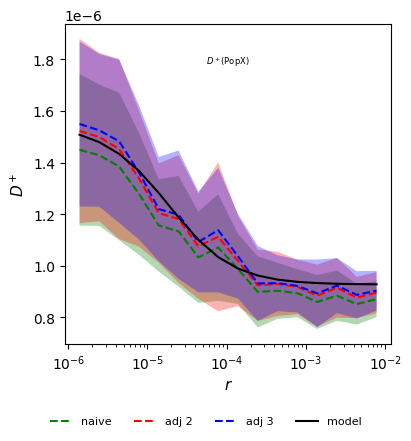

In [255]:
dpluspy.plotting.plot_D_plus_curves(
    models=model,
    means=[naive, stats, adj_stats],
    varcovs=[naive_varcovs, varcovs, adj_varcovs],
    bins=bins,
    pop_ids=["PopX"],
    ax_size=4,
    colors=["green", "red", "blue", "black"],
    labels=["naive", "adj 2", "adj 3", "model"]
)

In [18]:
import pickle

with open("adj_test.pkl", "rb") as fin:
    adj_sums = pickle.load(fin)
adj_stats, adj_varcovs = dpluspy.bootstrapping.bootstrap_stats(adj_sums)

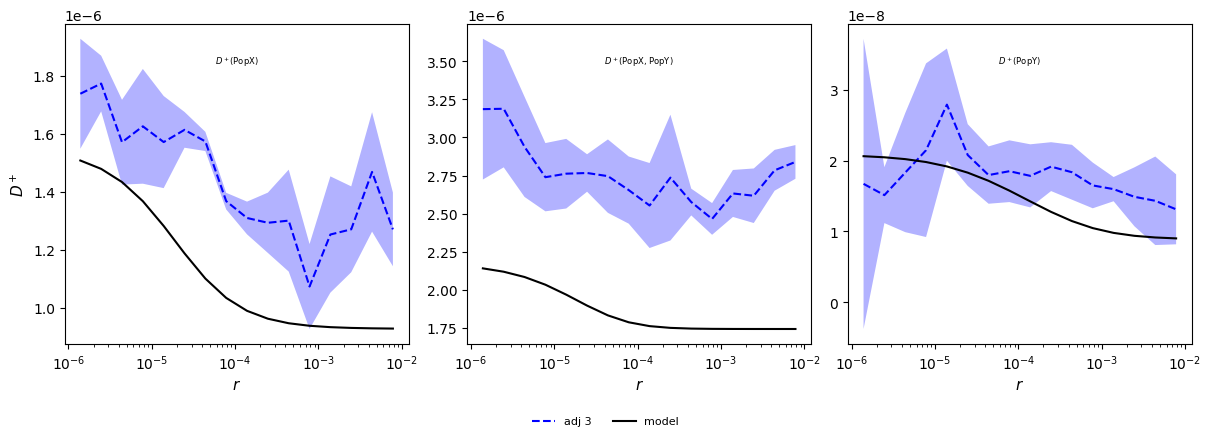

In [19]:
dpluspy.plotting.plot_D_plus_curves(
    models=model,
    means=adj_stats,
    varcovs=adj_varcovs,
    bins=bins,
    pop_ids=pop_ids,
    ax_size=4,
    colors=["blue", "black"],
    labels=["adj 3", "model"]
)